# pyfcfc $\leftrightarrow$ lsstypes: correlation-function data types

[lsstypes](https://github.com/adematti/lsstypes) provides container types
for large-scale-structure measurements: pair counts (`Count2`), correlation
estimators (`Count2Correlation`), multipole projections
(`Count2CorrelationPoles`), plus replica algebra (`sum`, `mean`, `cov`)
and serialisation.

`pyfcfc.external` converts a pyfcfc result dictionary into these objects,
so FCFC-speed pair counts can feed the lsstypes ecosystem directly:

* `to_lsstypes_counts(results, ...)` → dict of `Count2` leaves (DD, DR, RD, RR...);
* `to_lsstypes_correlation(results, estimator=...)` → `Count2Correlation`;
* `to_lsstypes(results, project='poles'|'wedges'|'wp'|'binned', ells=...)`
  → the projected objects.

Install the optional dependency with
`pip install git+https://github.com/adematti/lsstypes`.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.join(os.path.abspath(''), 'examples'))
sys.path.insert(0, os.path.join(os.path.abspath(''), os.pardir, 'examples'))
%matplotlib inline

from pyfcfc.boxes import py_compute_cf
from pyfcfc.utils import compute_multipoles
from pyfcfc.external import to_lsstypes, to_lsstypes_correlation, to_lsstypes_counts
import lsstypes
print('lsstypes', lsstypes.__version__)

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


lsstypes 1.1.0


In [2]:
from mocks import make_clustered_box
BOX = 1000.
data, w = make_clustered_box(30000, BOX, seed=42)
rand, wr = make_clustered_box(60000, BOX, seed=7, n_centers=1, clump_frac=0.)
s_edges = np.arange(0, 151, 5.)
res = py_compute_cf([data, rand], [w, wr], s_edges, None, 40,
                    label=['D', 'R'], bin=1, pair=['DD', 'DR', 'RR'],
                    cf=['(DD - 2 * DR + RR) / RR'], multipole=[0, 2, 4],
                    box=BOX)
print('pyfcfc pairs:', [k for k in res['pairs'] if len(k) == 2])

pyfcfc pairs: ['DD', 'DR', 'RR']


## 1. Pair counts as `Count2` leaves

The converter mirrors the $|\mu|$ counts onto pycorr/lsstypes' full
$[-1, 1]$ range (each half carries half of the ordered pairs) and stores
the normalizations and catalogue sizes in the leaves.

In [3]:
counts = to_lsstypes_counts(res)
print({name: type(leaf).__name__ for name, leaf in counts.items()})
dd = counts['DD']
print('coords:', list(dd.coords()), '| shape of counts:', dd.values('counts').shape)
print('norm (per bin):', dd.values('norm')[0, 0], '=', res['normalization']['DD'])
print('sizes:', dd.attrs)

{'DD': 'Count2', 'DR': 'Count2', 'RD': 'Count2', 'RR': 'Count2'}
coords: ['s', 'mu'] | shape of counts: (30, 80)
norm (per bin): 900478704.3481619 = 900478704.3481619
sizes: {'size1': 30008.484151326338, 'size2': 30008.484151326338}


## 2. Estimator and multipoles

`Count2Correlation` evaluates the estimator on the normalized counts;
`.project('poles')` performs the exact per-bin Legendre integration (the
same scheme as pycorr).

In [4]:
corr = to_lsstypes_correlation(res, 'landyszalay')
xi = corr.value()          # xi(s, mu) on the full mu range
poles = to_lsstypes(res, ells=[0, 2, 4])
print(type(corr).__name__, '->', type(poles).__name__, 'ells =', poles.ells)

# cross-checks against pyfcfc
xi_half = (res['pairs']['DD'] - 2*res['pairs']['DR'] + res['pairs']['RR']) / res['pairs']['RR']
print('xi(s, mu>0) identical to pyfcfc:', np.allclose(xi[:, 40:], xi_half, rtol=1e-10, atol=1e-12))
mp = compute_multipoles(xi_half, [0, 2, 4], method='exact')
print('poles identical to utils exact integration:',
      all(np.allclose(poles.get(ell).values('value'), mp[i], rtol=1e-10, atol=1e-12)
          for i, ell in enumerate((0, 2, 4))))

Count2Correlation

 -> Count2CorrelationPoles ells = [0, 2, 4]
xi(s, mu>0) identical to pyfcfc: True
poles identical to utils exact integration: True


OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


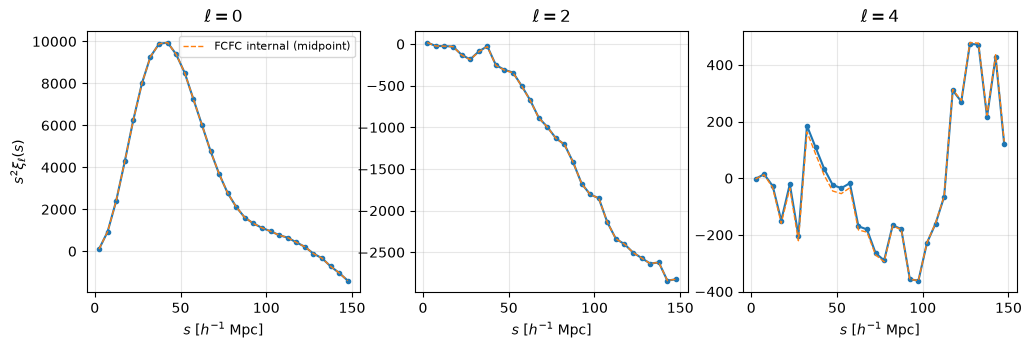

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for i, ell in enumerate((0, 2, 4)):
    pole = poles.get(ell)
    axes[i].plot(pole.s, pole.s**2 * pole.values('value'), '-o', ms=3)
    axes[i].plot(res['s'], res['s']**2 * res['multipoles'][0, i], '--', lw=1,
                 label='FCFC internal (midpoint)')
    axes[i].set_title(f'$\ell={ell}$'); axes[i].grid(alpha=.3)
    axes[i].set_xlabel(r'$s$ [$h^{-1}$ Mpc]')
axes[0].set_ylabel(r'$s^2 \xi_\ell(s)$'); axes[0].legend(fontsize=8)

## 3. Replica algebra: mean and covariance

lsstypes' strength is combining replicas. Here four mock replicas
(different weight realisations) are converted and combined; the covariance
of the monopole comes out of `lsstypes.cov`.

mean poles: Count2CorrelationPoles | cov shape: (60, 60)


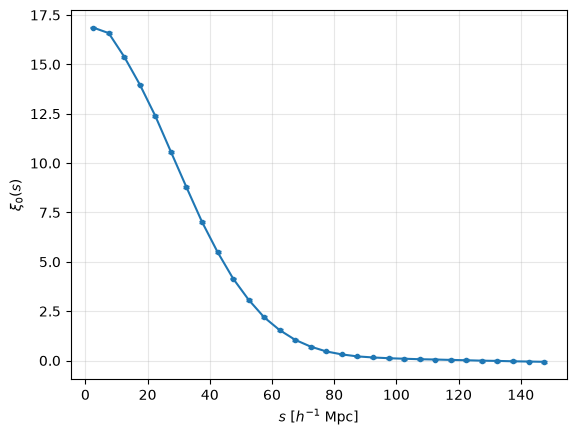

In [6]:
rng = np.random.default_rng(4)
replicas = []
for i in range(4):
    wi = rng.uniform(0.8, 1.2, len(data))
    ri = py_compute_cf([data, rand], [wi, wr], s_edges, None, 40,
                       label=['D', 'R'], bin=1, pair=['DD', 'DR', 'RR'], box=BOX)
    replicas.append(to_lsstypes_correlation(ri).project('poles', ells=[0, 2]))
mean = lsstypes.mean(replicas)
cov = lsstypes.cov(replicas)
std = cov.std()
print('mean poles:', type(mean).__name__, '| cov shape:', np.shape(cov.value()))
plt.errorbar(mean.get(0).s, mean.get(0).values('value'), yerr=std[0], fmt='-o', ms=3, capsize=2)
plt.xlabel(r'$s$ [$h^{-1}$ Mpc]'); plt.ylabel(r'$\xi_0(s)$'); plt.grid(alpha=.3)

## 4. Serialisation

`lsstypes.write/read` support `.pkl`, `.h5`/`.hdf5` (with h5py) and `.txt`.

In [7]:
lsstypes.write('poles_demo.pkl', poles)
back = lsstypes.read('poles_demo.pkl')
print('roundtrip identical:',
      np.allclose(back.get(0).values('value'), poles.get(0).values('value')))
import os; os.remove('poles_demo.pkl')

roundtrip identical: True


## 5. Natural estimator with analytic randoms, and $w_p$

For a periodic box without RR counts, the converter synthesizes the
analytic random-random counts (same convention as FCFC's `@@`); and
(s_perp, pi) results project onto $w_p$.

In [8]:
du = make_clustered_box(30000, BOX, seed=42)[0]
resu = py_compute_cf([du], [np.ones(len(du))], s_edges, None, 40, label=['D'],
                     bin=1, pair=['DD'], cf=['DD / @@ - 1'], multipole=[0], box=BOX)
nat = to_lsstypes(resu, estimator='natural', box_size=BOX, ells=[0])
print('natural xi0 vs FCFC DD/@@-1 multipoles: max diff',
      np.max(np.abs(nat.get(0).values('value') - resu['multipoles'][0][0])))

natural xi0 vs FCFC DD/@@-1 multipoles: max diff 1.0658141036401503e-14


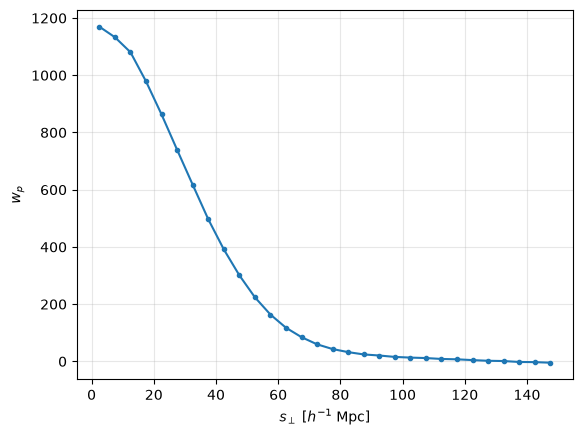

In [9]:
pi_edges = np.arange(0, 81, 5.)
resp = py_compute_cf([data, rand], [w, wr], s_edges, pi_edges, 0,
                     label=['D', 'R'], bin=2, pair=['DD', 'DR', 'RR'], box=BOX)
wp = to_lsstypes(resp, project='wp')
plt.plot(resp['s'], wp.values('value'), '-o', ms=3)
plt.xlabel(r'$s_\perp$ [$h^{-1}$ Mpc]'); plt.ylabel(r'$w_p$'); plt.grid(alpha=.3)

## Notes and caveats

* lsstypes stores $\xi(s, \mu)$ on the full $[-1, 1]$ range; pyfcfc only
  bins $|\mu|$. The converter mirrors the counts, which is exact for auto
  pairs and a (very good) statistical symmetry for cross pairs.
* `lsstypes.sum` weights replicas by the norm of the first count (DD);
  `pyfcfc.utils.add_pair_counts` accumulates each pair type with its own
  normalization (exact raw-count addition). The two coincide for
  unweighted, equal-size replicas and differ at the sub-percent level
  otherwise - use `add_pair_counts` for split-random accumulation.
* Multipole integration in lsstypes is the exact per-bin Legendre
  integral (pycorr's scheme); FCFC's internal multipoles use the midpoint
  rule - see notebook 02 and `pyfcfc.utils.compute_multipoles`.